In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

In [65]:

meg_calls = pd.read_csv(r"C:\Users\robab\OneDrive\2025\Tripleten\Review TripleTen project\sprint 4\megaline_calls.csv")
meg_internt = pd.read_csv(r"C:\Users\robab\OneDrive\2025\Tripleten\Review TripleTen project\sprint 4\megaline_internet.csv" , sep =",")
meg_messages = pd.read_csv(r"C:\Users\robab\OneDrive\2025\Tripleten\Review TripleTen project\sprint 4\megaline_messages.csv", sep =",")
meg_plans = pd.read_csv(r"C:\Users\robab\OneDrive\2025\Tripleten\Review TripleTen project\sprint 4\megaline_plans.csv", sep =",")
meg_users = pd.read_csv(r"C:\Users\robab\OneDrive\2025\Tripleten\Review TripleTen project\sprint 4\megaline_users.csv", sep =",")   

In [66]:
# data preprocessing and cleaning meg_calls 
print(meg_calls.info())
print('==' *20)
print(meg_calls.tail())
print('==' *20)
# check for missing values
print(meg_calls.isnull().sum())
# check for duplicates
print('==' *20)
print(meg_calls.duplicated().sum())
print('==' *20)
meg_calls.columns = (meg_calls.columns
                            .str.strip()
                            .str.lower() 
                            .str.replace(' ', '_'))
print(meg_calls.columns)
# convert data types
meg_calls['id'] = meg_calls['id'].astype(int)
print(meg_calls['id'].dtype)
# round up the duration column to the nearest whole number
meg_calls['duration'] =np.ceil(meg_calls['duration'])
print(meg_calls['duration'].head())
# covert the date column to datetime format
meg_calls['call_date'] = pd.to_datetime(meg_calls['call_date'])
print(meg_calls.head())
print()
print(meg_calls['call_date'].dtype)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None
              id  user_id   call_date  duration
137730  1499_199     1499  2018-11-21      8.72
137731  1499_200     1499  2018-10-20     10.89
137732  1499_201     1499  2018-09-21      8.12
137733  1499_202     1499  2018-10-10      0.37
137734  1499_203     1499  2018-12-29     13.86
id           0
user_id      0
call_date    0
duration     0
dtype: int64
0
Index(['id', 'user_id', 'call_date', 'duration'], dtype='object')
int64
0     9.0
1    14.0
2    15.0
3     6.0
4     5.0
Name: duration, dtype: float64
        id  user_id  call_date  duration
0   100093     1000 

In [67]:
# preprocessing and cleaning meg_internet
print(meg_internt.info())
print('==' *20)
print(meg_internt.columns)
print('==' *20)
print(meg_internt.tail())
print('==' *20)
# check for missing values
print(meg_internt.isnull().sum())
# check for duplicates
print('==' *20)
print(meg_internt.duplicated().sum())
print('==' *20)
meg_internt.columns = (meg_internt.columns
                            .str.strip()
                            .str.lower() 
                            .str.replace(' ', '_'))
print(meg_internt.columns)
# convert data types
meg_internt['id'] = meg_internt['id'].astype(int)

print(meg_internt['id'].dtype)

meg_internt['session_date'] = pd.to_datetime(meg_internt['session_date'])

print(meg_internt.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None
Index(['id', 'user_id', 'session_date', 'mb_used'], dtype='object')
              id  user_id session_date  mb_used
104820  1499_215     1499   2018-10-20   218.06
104821  1499_216     1499   2018-12-30   304.72
104822  1499_217     1499   2018-09-22   292.75
104823  1499_218     1499   2018-12-07     0.00
104824  1499_219     1499   2018-12-24   758.31


id              0
user_id         0
session_date    0
mb_used         0
dtype: int64
0
Index(['id', 'user_id', 'session_date', 'mb_used'], dtype='object')
int64
        id  user_id session_date  mb_used
0   100013     1000   2018-12-29    89.86
1  1000204     1000   2018-12-31     0.00
2  1000379     1000   2018-12-28   660.40
3  1000413     1000   2018-12-26   270.99
4  1000442     1000   2018-12-27   880.22


In [68]:
# ...existing code...
# Convert MB to GB and keep 2 decimals
meg_internt['mb_used_gb'] = np.ceil (meg_internt['mb_used']/1024)
print(meg_internt['mb_used_gb'].head())
# ...existing code...

0    1.0
1    0.0
2    1.0
3    1.0
4    1.0
Name: mb_used_gb, dtype: float64


In [69]:
# data preprocessing and cleaning meg_messages
print(meg_messages.info())
print('==' *20)   
print(meg_messages.tail())
print('==' *20) 
# check for missing values
print(meg_messages.isnull().sum())
# check for duplicates
print('==' *20)
print(meg_messages.duplicated().sum())
print('==' *20)

meg_messages.columns = (meg_messages.columns
                            .str.strip()
                            .str.lower() 
                            .str.replace(' ', '_')) 
print(meg_messages.columns)

# convert data types
meg_messages['id'] = meg_messages['id'].astype(int) 
print(meg_messages['id'].dtype)

meg_messages['message_date'] = pd.to_datetime(meg_messages['message_date'])
print(meg_messages.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None
             id  user_id message_date
76046  1497_526     1497   2018-12-24
76047  1497_536     1497   2018-12-24
76048  1497_547     1497   2018-12-31
76049  1497_558     1497   2018-12-24
76050  1497_613     1497   2018-12-23
id              0
user_id         0
message_date    0
dtype: int64
0
Index(['id', 'user_id', 'message_date'], dtype='object')
int64
        id  user_id message_date
0  1000125     1000   2018-12-27
1  1000160     1000   2018-12-31
2  1000223     1000   2018-12-31
3  1000251     1000   2018-12-27
4  1000255     1000   2018-12-26


In [70]:
# data preprocessing and cleaning meg_plans
print(meg_plans.info())
print('==' *20)
print(meg_plans.shape)
print('==' *20)
meg_plans.columns = (meg_plans.columns
                            .str.strip()
                            .str.lower() 
                            .str.replace(' ', '_'))
print(meg_plans.columns)

print(meg_plans.head())

print('==' *20)
# check for missing values
print(meg_plans.isnull().sum())
# check for duplicates
print('==' *20) 

print(meg_plans.duplicated().sum())
print('==' *20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes
None
(2, 8)
Index(['messages_included', 'mb_per_month_included', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
       'plan_name'],
      dtype='object')
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360

In [71]:
# data preprocessing and cleaning meg_users
print(meg_users.info()) 
print('==' *20)
print(meg_users.tail())    
print('==' *20) 
meg_users.columns = (meg_users.columns
                            .str.strip()
                            .str.lower()    
                            .str.replace(' ', '_'))
print(meg_users.columns)
# check for missing values
print(meg_users.isnull().sum())
# After missing value, we you do inspection to find out in which row data is missing
print(meg_users[meg_users['churn_date'].isna()].head())
# check for duplicates
print('==' *20)
print(meg_users.duplicated().sum())
print('==' *20)
# convert reg_date and churn_date to datetime format
meg_users['reg_date'] = pd.to_datetime(meg_users['reg_date'])   
meg_users['churn_date'] = pd.to_datetime(meg_users['churn_date'])
print(meg_users.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None
     user_id first_name   last_name  age  \
495     1495      Fidel      Sharpe   67   
496     1496      Ariel    Shepherd   49   
497     1497      Donte     Barrera   49   
498     1498       Scot  Williamson   51   
499     1499      Shena     Dickson   37   

                                          city    reg_date      plan  \
495  New York-Newark-Jersey City, NY-NJ-PA MSA  2018-09-04      surf   
496               New Orleans-M

In [72]:
# The number of calls made and minutes used per month
meg_users_call = meg_calls.merge(meg_users, on=['user_id'], how='inner')

# extract month from call_date and create a new column for it
meg_users_call['call_month'] = meg_users_call['call_date'].dt.month

# group by user_id and call_month to calculate the number of calls and minutes used per month
# Creates a new summary table
# One row per user per month
# No repeated values

calls_per_month = meg_users_call.groupby(['user_id', 'call_month'], as_index=False).agg(
        plan=('plan', 'first'),
        calls_count=('id', 'count'),
        minutes_per_month=('duration', 'sum')
    ).rename(columns={'call_month': 'month'})
print(calls_per_month.head())




   user_id  month      plan  calls_count  minutes_per_month
0     1000     12  ultimate           16              124.0
1     1001      8      surf           27              182.0
2     1001      9      surf           49              315.0
3     1001     10      surf           65              393.0
4     1001     11      surf           64              426.0


In [73]:
# The number of text message sent per month 
meg_user_message = meg_messages.merge(meg_users, on = ['user_id'], how = 'inner')

print (meg_user_message.head())


        id  user_id message_date first_name last_name  age  \
0  1000125     1000   2018-12-27   Anamaria     Bauer   45   
1  1000160     1000   2018-12-31   Anamaria     Bauer   45   
2  1000223     1000   2018-12-31   Anamaria     Bauer   45   
3  1000251     1000   2018-12-27   Anamaria     Bauer   45   
4  1000255     1000   2018-12-26   Anamaria     Bauer   45   

                                    city   reg_date      plan churn_date  
0  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  
1  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  
2  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  
3  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  
4  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  


In [74]:
#meg_user_message['message_month'] = meg_user_message['message_date'].dt.month
meg_user_message['message_month'] = meg_user_message['message_date'].dt.month
message_per_month = (meg_user_message .groupby(['user_id', 'message_month'], as_index=False) .agg(
         plan=('plan', 'first'),   
       message_per_month=('id', 'count')).rename(columns={'message_month': 'month'}))

print(message_per_month.head())


   user_id  month      plan  message_per_month
0     1000     12  ultimate                 11
1     1001      8      surf                 30
2     1001      9      surf                 44
3     1001     10      surf                 53
4     1001     11      surf                 36


In [75]:
# volume of internet traffic per month
meg_user_session = meg_internt.merge(meg_users, on = ['user_id'], how ='inner')
print(meg_user_session.head())

        id  user_id session_date  mb_used  mb_used_gb first_name last_name  \
0   100013     1000   2018-12-29    89.86         1.0   Anamaria     Bauer   
1  1000204     1000   2018-12-31     0.00         0.0   Anamaria     Bauer   
2  1000379     1000   2018-12-28   660.40         1.0   Anamaria     Bauer   
3  1000413     1000   2018-12-26   270.99         1.0   Anamaria     Bauer   
4  1000442     1000   2018-12-27   880.22         1.0   Anamaria     Bauer   

   age                                   city   reg_date      plan churn_date  
0   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  
1   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  
2   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  
3   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  
4   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  


In [76]:
# finding the month of the session date
meg_user_session['gb_month'] = meg_user_session['session_date'].dt.month
print(meg_user_session.head())

        id  user_id session_date  mb_used  mb_used_gb first_name last_name  \
0   100013     1000   2018-12-29    89.86         1.0   Anamaria     Bauer   
1  1000204     1000   2018-12-31     0.00         0.0   Anamaria     Bauer   
2  1000379     1000   2018-12-28   660.40         1.0   Anamaria     Bauer   
3  1000413     1000   2018-12-26   270.99         1.0   Anamaria     Bauer   
4  1000442     1000   2018-12-27   880.22         1.0   Anamaria     Bauer   

   age                                   city   reg_date      plan churn_date  \
0   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT   
1   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT   
2   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT   
3   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT   
4   45  Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT   

   gb_month  
0        12  
1        12  
2 

In [77]:
gb_per_month = (meg_user_session.groupby(['user_id', 'gb_month'], as_index=False) .agg(
         plan=('plan', 'first'),   
        session_count=('id', 'count'),
        gb_per_month=('mb_used_gb', 'sum')).rename(columns={'gb_month': 'month'})
)

print(gb_per_month.head())

   user_id  month      plan  session_count  gb_per_month
0     1000     12  ultimate              5           4.0
1     1001      8      surf             25          21.0
2     1001      9      surf             53          41.0
3     1001     10      surf             56          50.0
4     1001     11      surf             51          49.0


## The monthly revenue from each user 

(subtract the free package limit from the total number of calls,
 text messages, and data; multiply the result by the calling plan value; add the monthly charge depending on the calling plan)

In [78]:
print(meg_plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


In [79]:
print(calls_per_month.head())

   user_id  month      plan  calls_count  minutes_per_month
0     1000     12  ultimate           16              124.0
1     1001      8      surf           27              182.0
2     1001      9      surf           49              315.0
3     1001     10      surf           65              393.0
4     1001     11      surf           64              426.0


## for Surf plan 

- monthly_fee = 20
- free_minutes = 500
- free_messages = 50
- free_gb = 15
- extra_minute = 0.03
- extra_message = 0.03
- extra_gb = 10

# for Ultimate plan

- monthly_fee = 70
- free_minutes = 3000
- free_messages = 1000
- free_gb = 30
- extra_minute = 0.01
- extra_message = 0.01
- extra_gb = 7


In [80]:
meg_calls_message =calls_per_month.merge(message_per_month, on = ['user_id', 'plan', 'month'], how = 'outer')
print(meg_calls_message.head())

   user_id  month      plan  calls_count  minutes_per_month  message_per_month
0     1000     12  ultimate         16.0              124.0               11.0
1     1001      8      surf         27.0              182.0               30.0
2     1001      9      surf         49.0              315.0               44.0
3     1001     10      surf         65.0              393.0               53.0
4     1001     11      surf         64.0              426.0               36.0


In [81]:
meg_call_message_session = meg_calls_message.merge(gb_per_month, on = ['user_id', 'plan', 'month'], how = 'outer')
print(meg_call_message_session.head())

   user_id  month      plan  calls_count  minutes_per_month  \
0     1000     12  ultimate         16.0              124.0   
1     1001      8      surf         27.0              182.0   
2     1001      9      surf         49.0              315.0   
3     1001     10      surf         65.0              393.0   
4     1001     11      surf         64.0              426.0   

   message_per_month  session_count  gb_per_month  
0               11.0            5.0           4.0  
1               30.0           25.0          21.0  
2               44.0           53.0          41.0  
3               53.0           56.0          50.0  
4               36.0           51.0          49.0  


In [82]:
def calculate_revenue(row):
    if row['plan'] == 'surf':
        revenue = 20

        if row['minutes_per_month'] > 500:
            revenue += (row['minutes_per_month'] - 500) * 0.03

        if row['message_per_month'] > 50:
            revenue += (row['message_per_month'] - 50) * 0.03

        if row['gb_per_month'] > 15:
            revenue += (row['gb_per_month'] - 15) * 10

    else:  # ultimate
        revenue = 70

        if row['minutes_per_month'] > 3000:
            revenue += (row['minutes_per_month'] - 3000) * 0.01

        if row['message_per_month'] > 1000:
            revenue += (row['message_per_month'] - 1000) * 0.01

        if row['gb_per_month'] > 30:
            revenue += (row['gb_per_month'] - 30) * 7

    return revenue

In [83]:
meg_call_message_session['revenue'] = meg_call_message_session.apply(calculate_revenue, axis=1)
print(meg_call_message_session.head())
# Merge calls_per_month with meg_plans to get the plan details for each user
total_revenue_plan = (
    meg_call_message_session.groupby('plan')['revenue']
    .sum()
    .reset_index()
    .rename(columns={'revenue': 'total_revenue'})
)

print(total_revenue_plan)

   user_id  month      plan  calls_count  minutes_per_month  \
0     1000     12  ultimate         16.0              124.0   
1     1001      8      surf         27.0              182.0   
2     1001      9      surf         49.0              315.0   
3     1001     10      surf         65.0              393.0   
4     1001     11      surf         64.0              426.0   

   message_per_month  session_count  gb_per_month  revenue  
0               11.0            5.0           4.0    70.00  
1               30.0           25.0          21.0    80.00  
2               44.0           53.0          41.0   280.00  
3               53.0           56.0          50.0   370.09  
4               36.0           51.0          49.0   360.00  
       plan  total_revenue
0      surf      443771.18
1  ultimate      119973.00


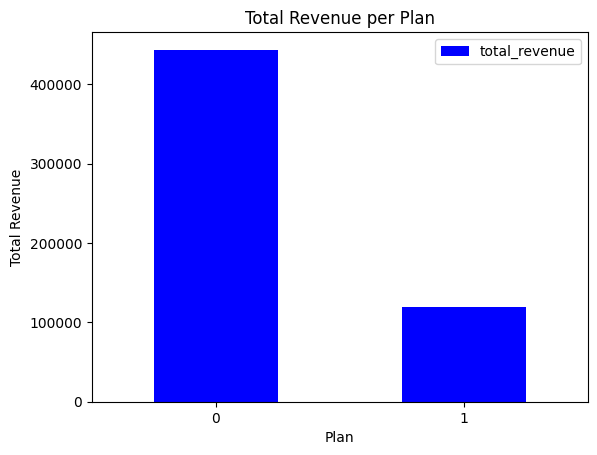

In [84]:
# total renveu per plan plot 
total_revenue_plan.plot(kind='bar', color=['blue', 'orange'])
plt.title('Total Revenue per Plan') 
plt.xlabel('Plan')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

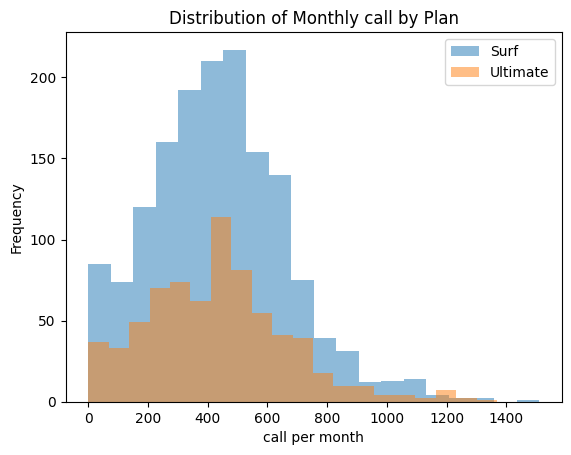

In [85]:
# Histogram of comparison of the calls per month for surf and ultimate plans
meg_call_message_session[meg_call_message_session['plan']=='surf']['minutes_per_month'].plot(
    kind='hist', bins=20, alpha=0.5, label='Surf'
)
meg_call_message_session[meg_call_message_session['plan']=='ultimate']['minutes_per_month'].plot(
    kind='hist', bins=20, alpha=0.5, label='Ultimate'
)

plt.legend()
plt.title("Distribution of Monthly call by Plan")
plt.xlabel("call per month")
plt.ylabel("Frequency")
plt.show()


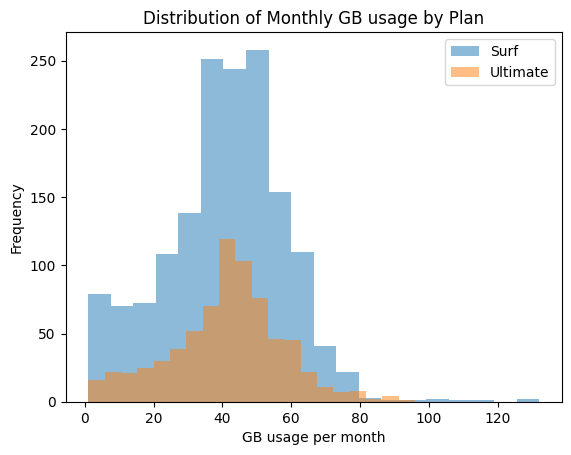

In [86]:
# Histogram of comparison of the message per month for surf and ultimate plans
meg_call_message_session[meg_call_message_session['plan']=='surf']['gb_per_month'].plot(
    kind='hist', bins=20, alpha=0.5, label='Surf'
)
meg_call_message_session[meg_call_message_session['plan']=='ultimate']['gb_per_month'].plot(
    kind='hist', bins=20, alpha=0.5, label='Ultimate'
)

plt.legend()
plt.title("Distribution of Monthly GB usage by Plan")
plt.xlabel("GB usage per month")
plt.ylabel("Frequency")
plt.show()

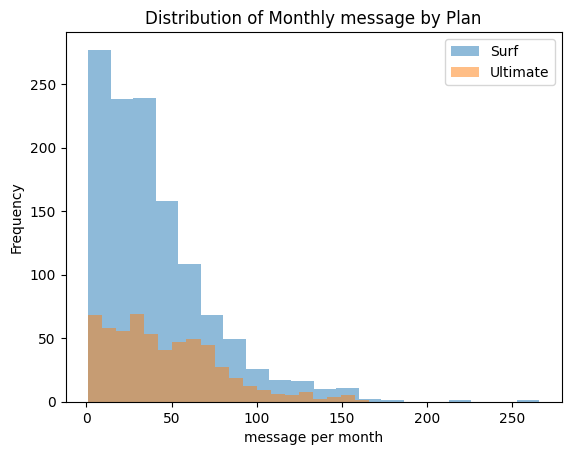

In [87]:
# Histogram of comparison of the session per month for surf and ultimate plans
meg_call_message_session[meg_call_message_session['plan']=='surf']['message_per_month'].plot(
    kind='hist', bins=20, alpha=0.5, label='Surf'
)
meg_call_message_session[meg_call_message_session['plan']=='ultimate']['message_per_month'].plot(
    kind='hist', bins=20, alpha=0.5, label='Ultimate'
)

plt.legend()
plt.title("Distribution of Monthly message by Plan")
plt.xlabel("message per month")
plt.ylabel("Frequency")
plt.show()

In [88]:
# Total revenue by plan

# Step 3. Analyze the data

Describe the customers' behavior. Find the minutes, texts, and volume of data the users of each plan require per month. Calculate the mean, variance, and standard deviation. Plot histograms. Describe the distributions. 

In [89]:
# customer behaviour analysis based on the usage of calls, messages, and internet traffic for each plan
# Calculate average usage for each plan
average_usage = meg_call_message_session.groupby('plan').agg(average_mintues = ('minutes_per_month', 'mean'),
                                                        average_message = ('message_per_month', 'mean'),    
                                                        average_gb = ('gb_per_month', 'mean'))
print(average_usage)




          average_mintues  average_message  average_gb
plan                                                  
surf           436.519741        40.109656   40.526958
ultimate       434.676017        46.296233   41.137691


In [90]:
# variance and standard deviation of useage for each plan
usage_variance_std = meg_call_message_session.groupby('plan').agg(minutes_variance = ('minutes_per_month', 'var'),
                                                                minutes_std = ('minutes_per_month', 'std'),
                                                                message_variance = ('message_per_month', 'var'),
                                                                message_std = ('message_per_month', 'std'),
                                                                gb_variance = ('gb_per_month', 'var'),
                                                                gb_std = ('gb_per_month', 'std'))
print(usage_variance_std)

          minutes_variance  minutes_std  message_variance  message_std  \
plan                                                                     
surf          52571.063243   229.283805       1091.344231    33.035500   
ultimate      56573.632247   237.852123       1085.183108    32.942118   

          gb_variance     gb_std  
plan                              
surf       305.726633  17.485040  
ultimate   271.224747  16.468902  



# Step 4. Test the hypotheses

- The average revenue from users of Ultimate and Surf calling plans differs.

- The average revenue from users in NY-NJ area is different from that of the users from other regions.
You decide what alpha value to use.
       
## 
**Null hypothesis H0:**

 The average monthly revenue of Surf users equals the average monthly revenue of Ultimate users.

**Alternative hypothesis H1:** 

The average monthly revenue of Surf users differs from the average monthly revenue of Ultimate users.
Because you said differs, this is a two-sided test.
Use an independent two-sample t-test (Welch version is best in practice): scipy.stats.ttest_ind(..., equal_var=False).

**Row condition: meg_call_message_session['plan'] == 'surf'**

- creates a boolean mask (True/False) for each row.
_  True only where plan is 'surf'.

_ **Column selection: 'revenue'**

selects only the revenue column.
So the result is a Series of revenue values for Surf users only.
                                                                                                                     


In [95]:

alpha = 0.05

surf_revenue = meg_call_message_session.loc[
    meg_call_message_session['plan'] == 'surf', 'revenue'
]
ultimate_revenue = meg_call_message_session.loc[
    meg_call_message_session['plan'] == 'ultimate', 'revenue'
]

results = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False, nan_policy='omit')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")



p-value: 2.3248333100718758e-97
We reject the null hypothesis


In [ ]:
# Test hypothesis for for average revenu from users in NY-NJ are is different from the average revenue from users in other areas
alpha = 0.05
print(meg_call_message_session.head())

print(meg_users.head())


   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  
0 2018-12-24  ultimate        NaT  
1 2018-08-13      surf        NaT  
2 2018-10-21      surf        NaT  
3 2018-01-28      surf        NaT  
4 2018-05-23      surf        NaT  
   user_id  month      plan  calls_count  minutes_per_month  \
0     1000     12  ultimate         16.0              124.0   
1     1001      8      surf         27.0              182.0   
2     1001      9      surf         49.0              315.0   
3     1001     10      surf         65.0           

In [106]:
# Merge meg_call_message_session with meg_users to get the city information for each user
meg_user_city_revenue = meg_call_message_session.merge(meg_users[['user_id', 'city']], on='user_id', how='left')
print(meg_user_city_revenue.sample(10))

      user_id  month  plan  calls_count  minutes_per_month  message_per_month  \
1677     1362      2  surf        106.0              811.0               58.0   
1307     1278     12  surf         50.0              393.0               24.0   
1762     1381     10  surf         61.0              502.0              224.0   
583      1123     10  surf         88.0              620.0               27.0   
2222     1484     12  surf         44.0              384.0               83.0   
1334     1285     10  surf         52.0              375.0               28.0   
343      1073      7  surf         44.0              325.0                NaN   
965      1201      7  surf         75.0              515.0                4.0   
301      1066      5  surf         63.0              443.0               27.0   
1650     1358      7  surf         57.0              369.0                3.0   

      session_count  gb_per_month  revenue  \
1677           40.0          32.0   199.57   
1307           7

In [115]:
meg_user_city_revenue['city'] = meg_user_city_revenue['city'].str.strip()

NY_NJ_revenue = meg_user_city_revenue.loc[
    meg_user_city_revenue['city'].str.contains('NY-NJ', na=False), 'revenue'
]

city_revenue = meg_user_city_revenue.loc[
    ~meg_user_city_revenue['city'].str.contains('NY-NJ', na=False), 'revenue'
]

results = st.ttest_ind(NY_NJ_revenue, city_revenue, equal_var=False, nan_policy='omit')
print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value: 0.0046325620587001
We reject the null hypothesis


In [112]:
print(meg_user_city_revenue['city'].unique()[:10])
print(NY_NJ_revenue.shape)
print(city_revenue.shape)
print(NY_NJ_revenue.head())
print(city_revenue.head())

['Atlanta-Sandy Springs-Roswell, GA MSA' 'Seattle-Tacoma-Bellevue, WA MSA'
 'Las Vegas-Henderson-Paradise, NV MSA' 'Tulsa, OK MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Grand Rapids-Kentwood, MI MSA'
 'Orlando-Kissimmee-Sanford, FL MSA'
 'San Jose-Sunnyvale-Santa Clara, CA MSA' 'Cleveland-Elyria, OH MSA']
(0,)
(2293,)
Series([], Name: revenue, dtype: float64)
0     70.00
1     80.00
2    280.00
3    370.09
4    360.00
Name: revenue, dtype: float64
